<a href="https://colab.research.google.com/github/Shalaka127/Store-Sales-Forecasting-Using-Machine-Learning-case-study/blob/main/Store_Sales_Forecasting_Using_Machine_Learning_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Store Sales Forecasting Using Time Series Analysis and Machine Learning

## Predicting Future Daily Sales for Retail Stores

### Project Overview

Accurate sales forecasting is critical for retail businesses because it enables efficient inventory management, workforce planning, promotional strategy development, and revenue forecasting.

In this project, we analyze historical sales data from 1115 retail stores and build forecasting models to predict future daily sales. The dataset includes information about customer traffic, promotions, holidays, store characteristics, and competition factors that influence store performance.

### Business Problem

Retail sales fluctuate due to seasonality, promotions, holidays, customer behavior, and competitive activity. The company wants to forecast future daily sales to support strategic and operational decision-making.

### Business Objective

Develop a forecasting system capable of predicting future store sales using historical sales patterns and business-related variables.

### Data Science Objective

Build a time series forecasting model using Prophet to predict future sales trends while incorporating seasonality and holiday effects.

# 1. Data Collection and Dataset Loading

## Objective

The first step is to import the required libraries and load the datasets into the analysis environment.

Two datasets are provided:

### Sales Dataset
Contains daily transaction information for each store.

### Store Dataset
Contains static information about stores such as store type, assortment level, competition details, and promotional programs.

These datasets will later be combined to create a comprehensive view of store performance.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime


In [2]:
# You will need to mount your drive using the following commands:
# For more information regarding mounting, please check this out: https://stackoverflow.com/questions/46986398/import-data-into-google-colaboratory

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Understanding the Sales Dataset



In [3]:
# You have to include the full link to the csv file containing your dataset
sales_train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data science case studies /Sales department/train (1).csv')

/tmp/ipykernel_1004/1492301119.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data science case studies /Sales department/train (1).csv')


In [4]:
sales_train_df.head(5)
# almost a million observation
# 1115 unique stores
# Note that sales is the target variable (that's what we are trying to predict)

# Id: transaction ID (combination of Store and date)
# Store: unique store Id
# Sales: sales/day, this is the target variable
# Customers: number of customers on a given day
# Open: Boolean to say whether a store is open or closed (0 = closed, 1 = open)
# Promo: describes if store is running a promo on that day or not
# StateHoliday: indicate which state holiday (a = public holiday, b = Easter holiday, c = Christmas, 0 = None)
# SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools

#- Data Source: https://www.kaggle.com/c/rossmann-store-sales/data



,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
sales_train_df.tail(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017199,1106,2,2013-01-01,0,0,0,0,a,1
1017200,1107,2,2013-01-01,0,0,0,0,a,1
1017201,1108,2,2013-01-01,0,0,0,0,a,1
1017202,1109,2,2013-01-01,0,0,0,0,a,1
1017203,1110,2,2013-01-01,0,0,0,0,a,1
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


In [6]:
sales_train_df.info()
# 9 columns in total
# 8 features, each contains 1017209 data points
# 1 target variable (sales)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [7]:
sales_train_df.describe()
# Average sales amount per day = 5773 Euros, minimum sales per day = 0, maximum sales per day = 41551
# Average number of customers = 633, minimum number of customers = 0, maximum number of customers = 7388

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


# 3. Understanding the Store Information Dataset


In [8]:
store_info_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data science case studies /Sales department/store.csv')

# StoreType: categorical variable to indicate type of store (a, b, c, d)
# Assortment: describes an assortment level: a = basic, b = extra, c = extended
# CompetitionDistance (meters): distance to closest competitor store
# CompetitionOpenSince [Month/Year]: provides an estimate of the date when competition was open
# Promo2: Promo2 is a continuing and consecutive promotion for some stores (0 = store is not participating, 1 = store is participating)
# Promo2Since [Year/Week]: date when the store started participating in Promo2
# PromoInterval: describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store




In [9]:
store_info_df.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
# Let's do the same for the store_info_df data
# Note that the previous dataframe includes the transactions recorded per day (in millions)
# This dataframe only includes information about the unique 1115 stores that are part of this study
store_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [11]:
store_info_df.describe()
# on average, the competition distance is 5404 meters away (5.4 kms)

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


# 4. Exploratory Data Analysis (Sales Dataset)

## Objective

Exploratory Data Analysis helps us understand customer behavior, sales patterns, and operational characteristics of the stores.

The goals of this analysis are:

- Identify data quality issues
- Understand feature distributions
- Detect outliers
- Examine customer traffic patterns
- Understand sales behavior

<Axes: >

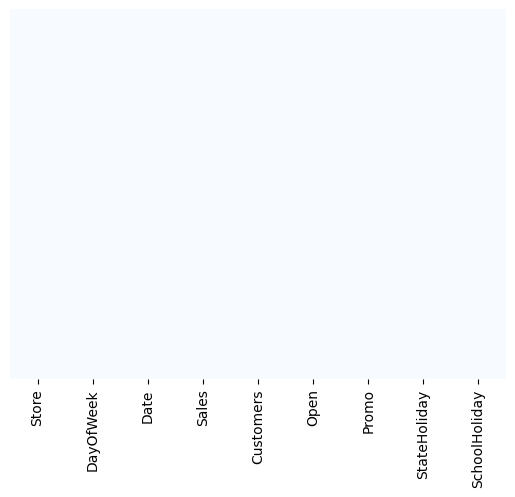

In [13]:
# Let's see if we have any missing data, luckily we don't!
 # sns.heatmap(sales_train_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")
sns.heatmap(sales_train_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")


### Missing Values Analysis

- The missing values visualization indicates that the dataset contains **no missing values** across all features.
- All columns appear complete, with no null or NaN entries detected.
- Since the dataset is fully populated, no imputation or missing-value treatment is required.
- The absence of missing data helps ensure reliable analysis, modeling, and forecasting results.
- Data preprocessing can proceed directly to feature engineering, visualization, and model development stages.


array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'DayOfWeek'}>,
        <Axes: title={'center': 'Sales'}>],
       [<Axes: title={'center': 'Customers'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'Promo'}>],
       [<Axes: title={'center': 'SchoolHoliday'}>, <Axes: >, <Axes: >]],
      dtype=object)

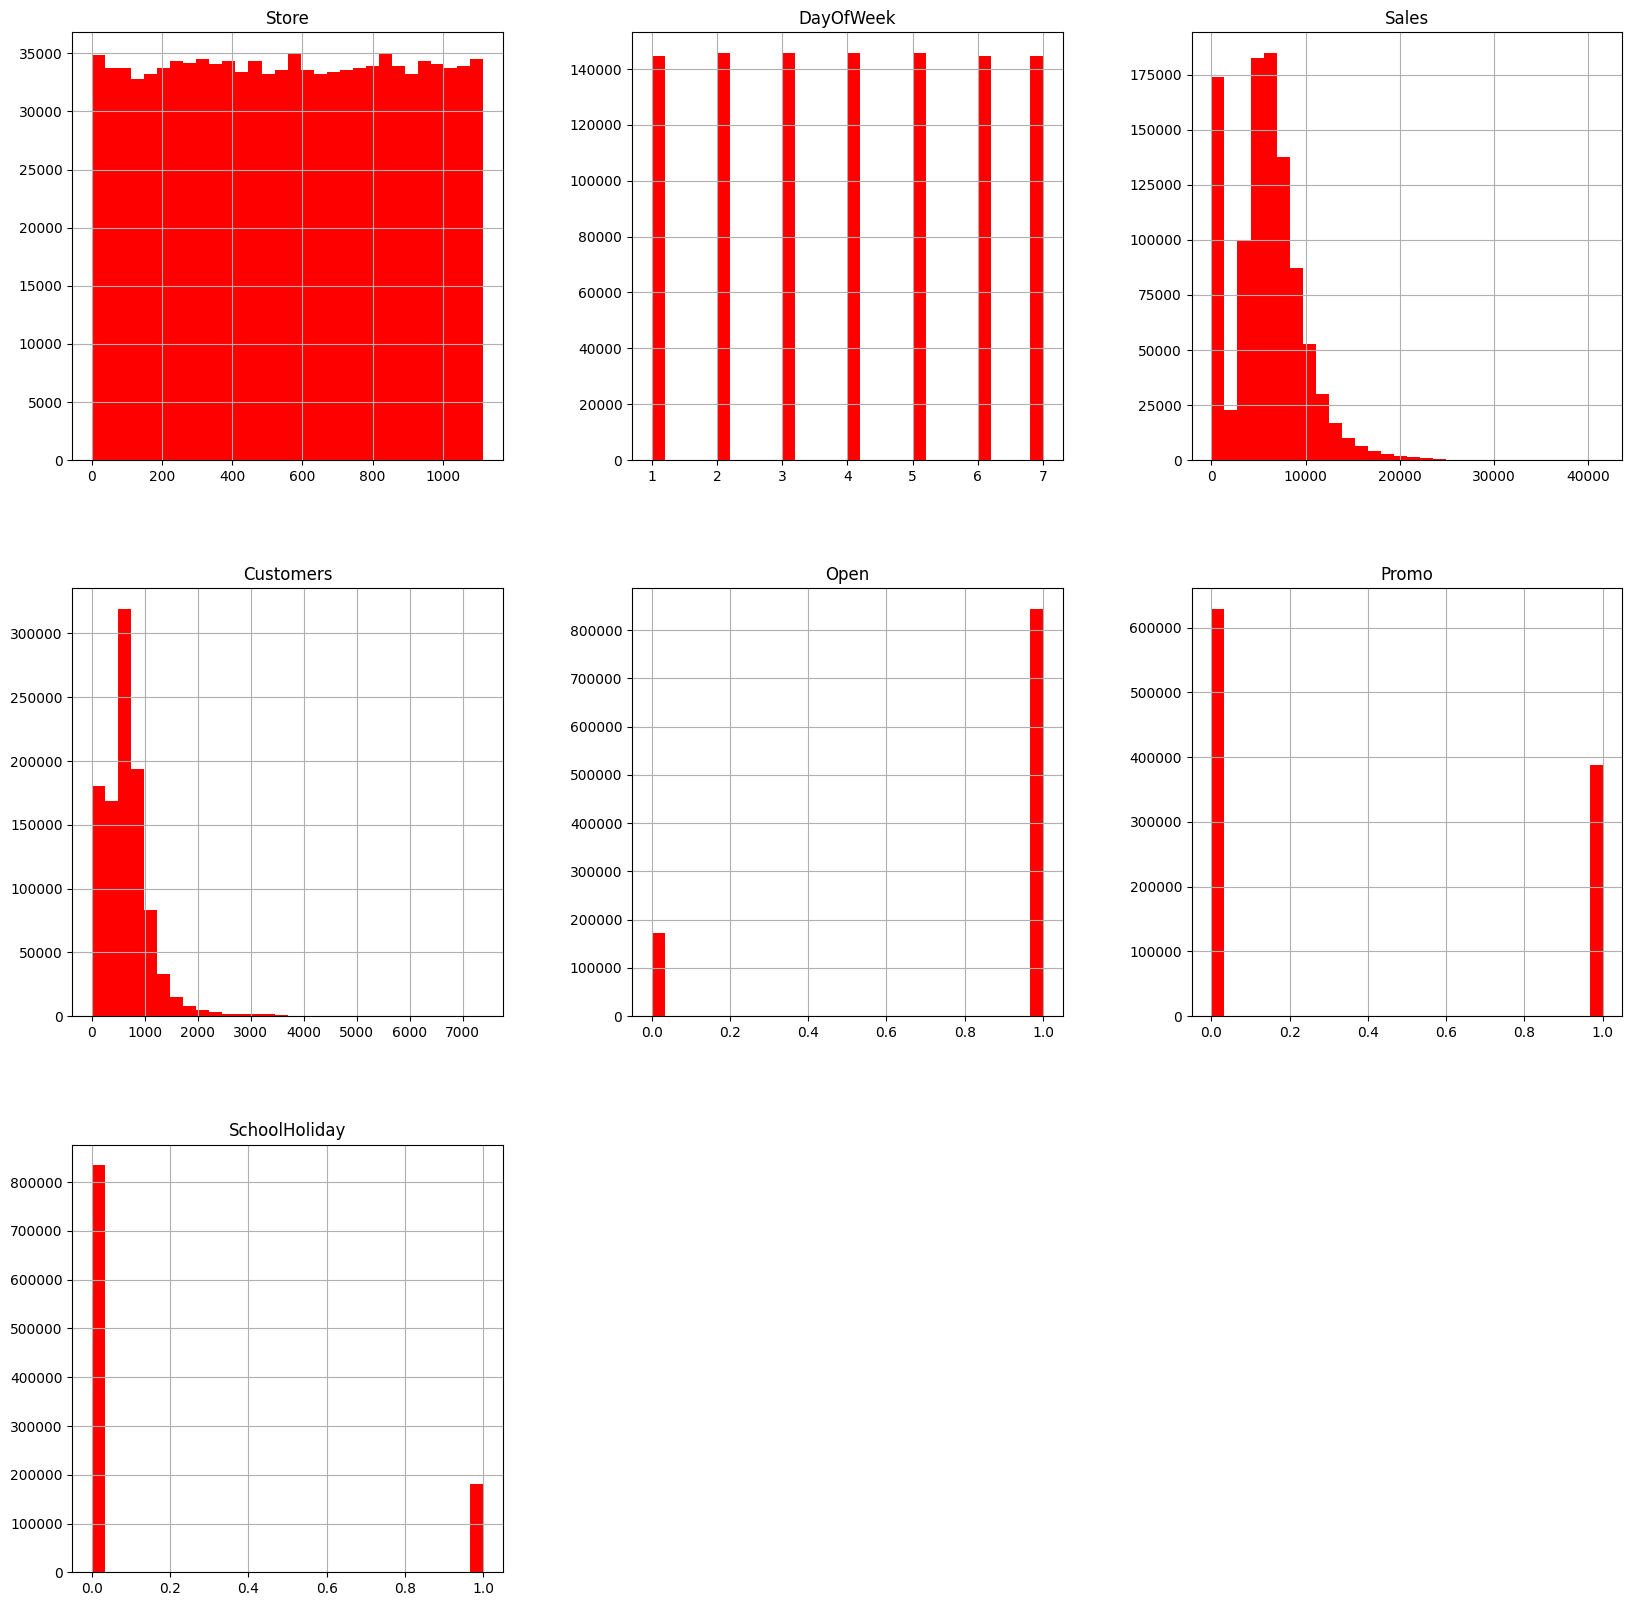

In [14]:
sales_train_df.hist(bins = 30, figsize = (20,20), color = 'r')
# Average 600 customers per day, maximum is 4500 (note that we can't see the outlier at 7388!)
# Data is equally distibuted across various Days of the week (~150000 observations x 7 day = ~1.1 million observation)
# Stores are open ~80% of the time
# Data is equally distributed among all stores (no bias)
# Promo #1 was running ~40% of the time
# Average sales around 5000-6000 Euros
# School holidays are around ~18% of the time



### Distribution Analysis Observations

- **Store** IDs are uniformly distributed, indicating that sales records are fairly balanced across different stores.
- **DayOfWeek** is evenly distributed across all seven days, suggesting consistent data collection throughout the week.
- **Sales** exhibits a strong right-skewed distribution, where most sales values are relatively low to moderate, while a small number of observations record exceptionally high sales.
- **Customers** also shows a right-skewed distribution, indicating that most stores receive a moderate number of customers, with a few stores experiencing very high customer traffic.
- The similarity between the **Sales** and **Customers** distributions suggests a positive relationship between customer count and sales revenue.
- **Open** is highly imbalanced, with most observations corresponding to stores being open (value = 1), while only a small proportion represent closed stores (value = 0).
- **Promo** is moderately imbalanced, with more observations having no promotion than promotion periods, although both classes are well represented.
- **SchoolHoliday** is highly imbalanced, with the majority of observations occurring during non-school-holiday periods.
- The presence of long tails in **Sales** and **Customers** indicates potential outliers that may require scaling or transformation before predictive modeling.



In [15]:
sales_train_df['Customers'].max()

7388

## Store Operational Analysis

Before forecasting sales, it is important to distinguish between stores that are open and those that are closed.

Since closed stores generate zero sales, including them may introduce unnecessary noise into the forecasting model.

Therefore, only open stores are retained for further analysis.

In [16]:
# Let's see how many stores are open and closed!
closed_train_df        = sales_train_df[sales_train_df['Open'] == 0]
open_train_df          = sales_train_df[sales_train_df['Open'] == 1]


In [17]:
# Count the number of stores that are open and closed
print("Total =", len(sales_train_df))
print("Number of closed stores =", len(closed_train_df))
print("Number of open stores =", len(open_train_df))

Total = 1017209
Number of closed stores = 172817
Number of open stores = 844392


In [18]:
# only keep open stores and remove closed stores
sales_train_df = sales_train_df[sales_train_df['Open'] == 1]

In [19]:
sales_train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1


In [20]:
# Let's drop the open column since it has no meaning now
sales_train_df.drop(['Open'], axis=1, inplace=True)

In [21]:
sales_train_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1
...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1
1016827,733,2,2013-01-01,10765,2377,0,a,1
1016863,769,2,2013-01-01,5035,1248,0,a,1
1017042,948,2,2013-01-01,4491,1039,0,a,1


In [22]:
sales_train_df.describe()
# Average sales = 6955 Euros,	average number of customers = 762	(went up)

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000


# 5. Exploratory Data Analysis (Store Information Dataset)

## Objective

The purpose of this analysis is to understand store characteristics and identify missing values.

Special attention is given to:

- Competition-related variables
- Promotion-related variables
- Store characteristics

These features may influence future sales performance.

<Axes: >

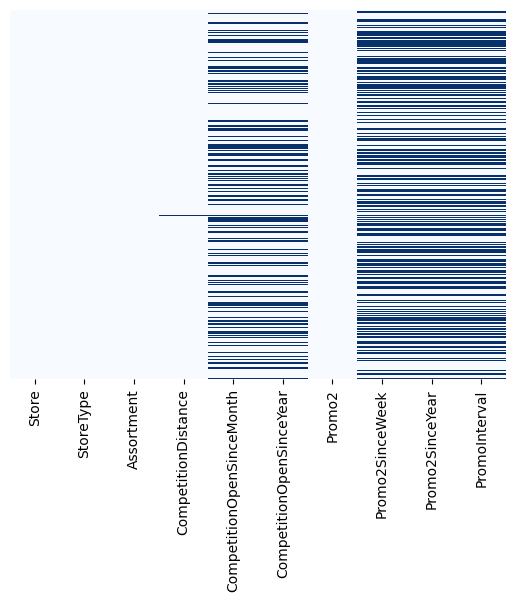

In [24]:
# Let's see if we have any missing data in the store information dataframe!
sns.heatmap(store_info_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")


### Missing Values Observation

- Missing values are mainly present in **competition** and **promotion-related** features.
- **CompetitionDistance** has very few missing values.
- **CompetitionOpenSinceMonth** and **CompetitionOpenSinceYear** contain moderate missing data.
- **Promo2SinceWeek**, **Promo2SinceYear**, and **PromoInterval** have a significant number of missing values.
- Missing values in promotion-related variables likely indicate stores that do not participate in the **Promo2** program.

Missing data is concentrated in competition and promotion features and should be handled appropriately before model training.

In [26]:
# Let's take a look at the missing values in the 'CompetitionDistance'
# Only 3 rows are missing
store_info_df[store_info_df['CompetitionDistance'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [27]:
# Let's take a look at the missing values in the 'CompetitionOpenSinceMonth'
# many rows are missing = 354 (almost one third of the 1115 stores)
store_info_df[store_info_df['CompetitionOpenSinceMonth'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [28]:
store_info_df[ store_info_df['Promo2'] == 0]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


## Missing Value Treatment

Real-world business datasets often contain incomplete information.

Missing values are addressed using business logic and statistical imputation techniques to ensure data quality before modeling.

In [31]:
# It seems like if 'promo2' is zero, 'promo2SinceWeek', 'Promo2SinceYear', and 'PromoInterval' information is set to zero
# There are 354 rows where 'CompetitionOpenSinceYear' and 'CompetitionOpenSinceMonth' is missing
# Let's set these values to zeros
str_cols = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']

for str in str_cols:
    store_info_df [str].fillna(0, inplace = True)

/tmp/ipykernel_1004/3285450880.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store_info_df [str].fillna(0, inplace = True)


<Axes: >

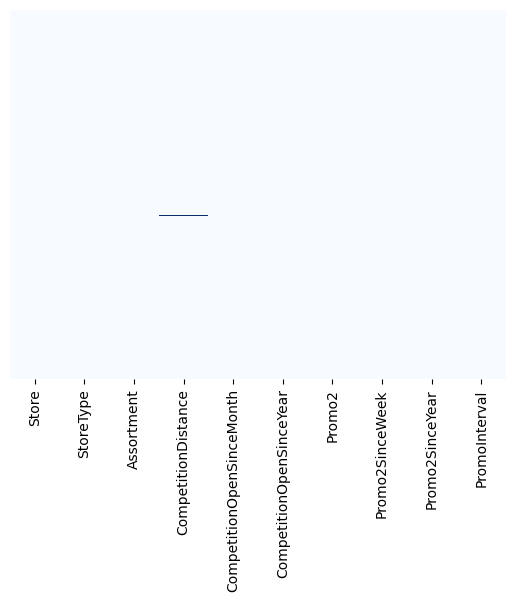

In [30]:
sns.heatmap(store_info_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")


In [32]:
# There are 3 rows with 'competitionDistance' values missing, let's fill them up with with average values of the 'CompetitionDistance' column
store_info_df['CompetitionDistance'].fillna(store_info_df['CompetitionDistance'].mean(), inplace = True)

/tmp/ipykernel_1004/1544909506.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  store_info_df['CompetitionDistance'].fillna(store_info_df['CompetitionDistance'].mean(), inplace = True)


<Axes: >

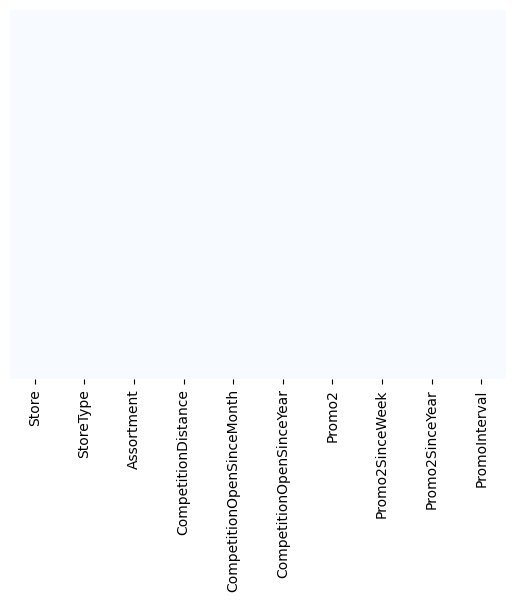

In [33]:
sns.heatmap(store_info_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")

array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'CompetitionDistance'}>,
        <Axes: title={'center': 'CompetitionOpenSinceMonth'}>],
       [<Axes: title={'center': 'CompetitionOpenSinceYear'}>,
        <Axes: title={'center': 'Promo2'}>,
        <Axes: title={'center': 'Promo2SinceWeek'}>],
       [<Axes: title={'center': 'Promo2SinceYear'}>, <Axes: >, <Axes: >]],
      dtype=object)

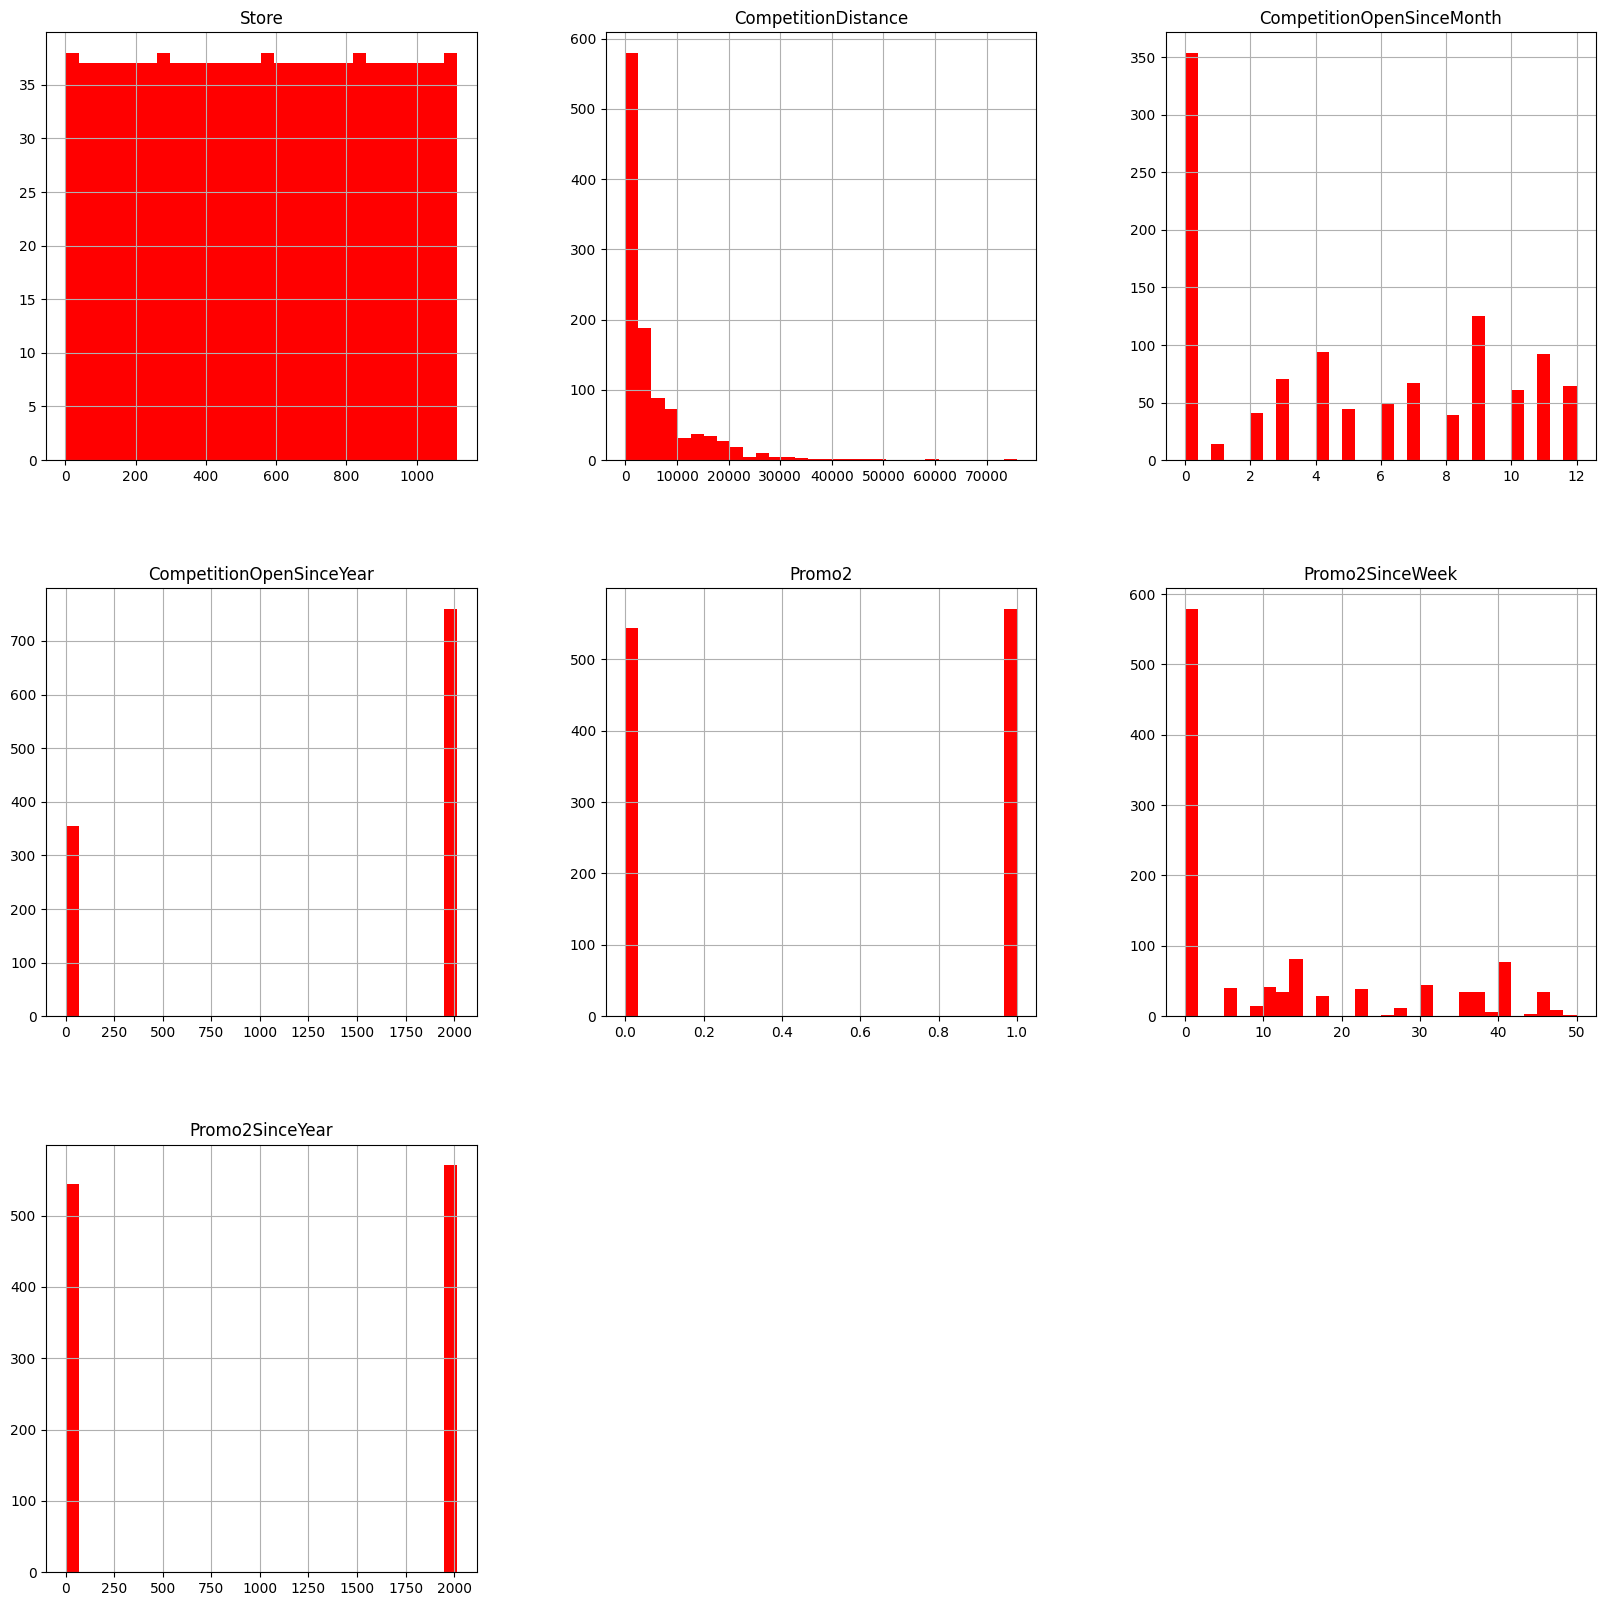

In [34]:
store_info_df.hist(bins = 30, figsize = (20,20), color = 'r')
# half of stores are involved in promo 2
# half of the stores have their competition at a distance of 0-3000m (3 kms away)

### Store Dataset Distribution Observations

- **Store** IDs are uniformly distributed across all stores.
- **CompetitionDistance** is highly right-skewed, indicating that most stores have nearby competitors, while a few face competition from much farther distances.
- **CompetitionOpenSinceMonth** values are spread across different months, with some months having higher frequencies than others.
- **CompetitionOpenSinceYear** is concentrated around recent years, suggesting that most competitors opened relatively recently.
- **Promo2** is nearly balanced between participating and non-participating stores.
- **Promo2SinceWeek** is unevenly distributed, with certain weeks showing higher promotion activity.
- **Promo2SinceYear** is concentrated in a few specific years, indicating that promotion programs were introduced during selected periods.

 Competition-related features are skewed and may contain outliers, while promotion-related variables show distinct patterns that could significantly influence store sales performance.

# 6. Data Integration

## Merging Sales and Store Information

The sales dataset contains daily transactional records, while the store dataset contains store-level attributes.

To create a complete analytical dataset, both datasets are merged using the Store identifier.

This consolidated dataset will serve as the foundation for feature engineering and forecasting.

In [35]:
# Let's merge both data frames together based on 'store'
sales_train_all_df = pd.merge(sales_train_df, store_info_df, how = 'inner', on = 'Store')

In [36]:
sales_train_all_df.to_csv('test.csv', index=False)


In [37]:
sales_train_all_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,0
844388,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,0
844389,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,0.0,0.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct"
844390,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,0.0,0.0,0,0.0,0.0,0


# 7. Feature Relationship Analysis

## Objective

Correlation analysis helps identify variables that have strong relationships with sales.

Understanding these relationships provides valuable business insights and helps identify important sales drivers.

Key questions include:

- Do promotions increase sales?
- Does customer traffic impact revenue?
- Does competition affect performance?

In [40]:
correlations = sales_train_all_df.select_dtypes(include=['number']).corr()['Sales'].sort_values()
correlations

# customers and promo are positively correlated with the sales
# Promo2 does not seem to be effective at all

,Sales
DayOfWeek,-0.178736
Promo2SinceYear,-0.127621
Promo2,-0.127596
Promo2SinceWeek,-0.058476
CompetitionDistance,-0.036343
CompetitionOpenSinceMonth,-0.018370
CompetitionOpenSinceYear,0.005266
Store,0.007710
SchoolHoliday,0.038617
Promo,0.368145


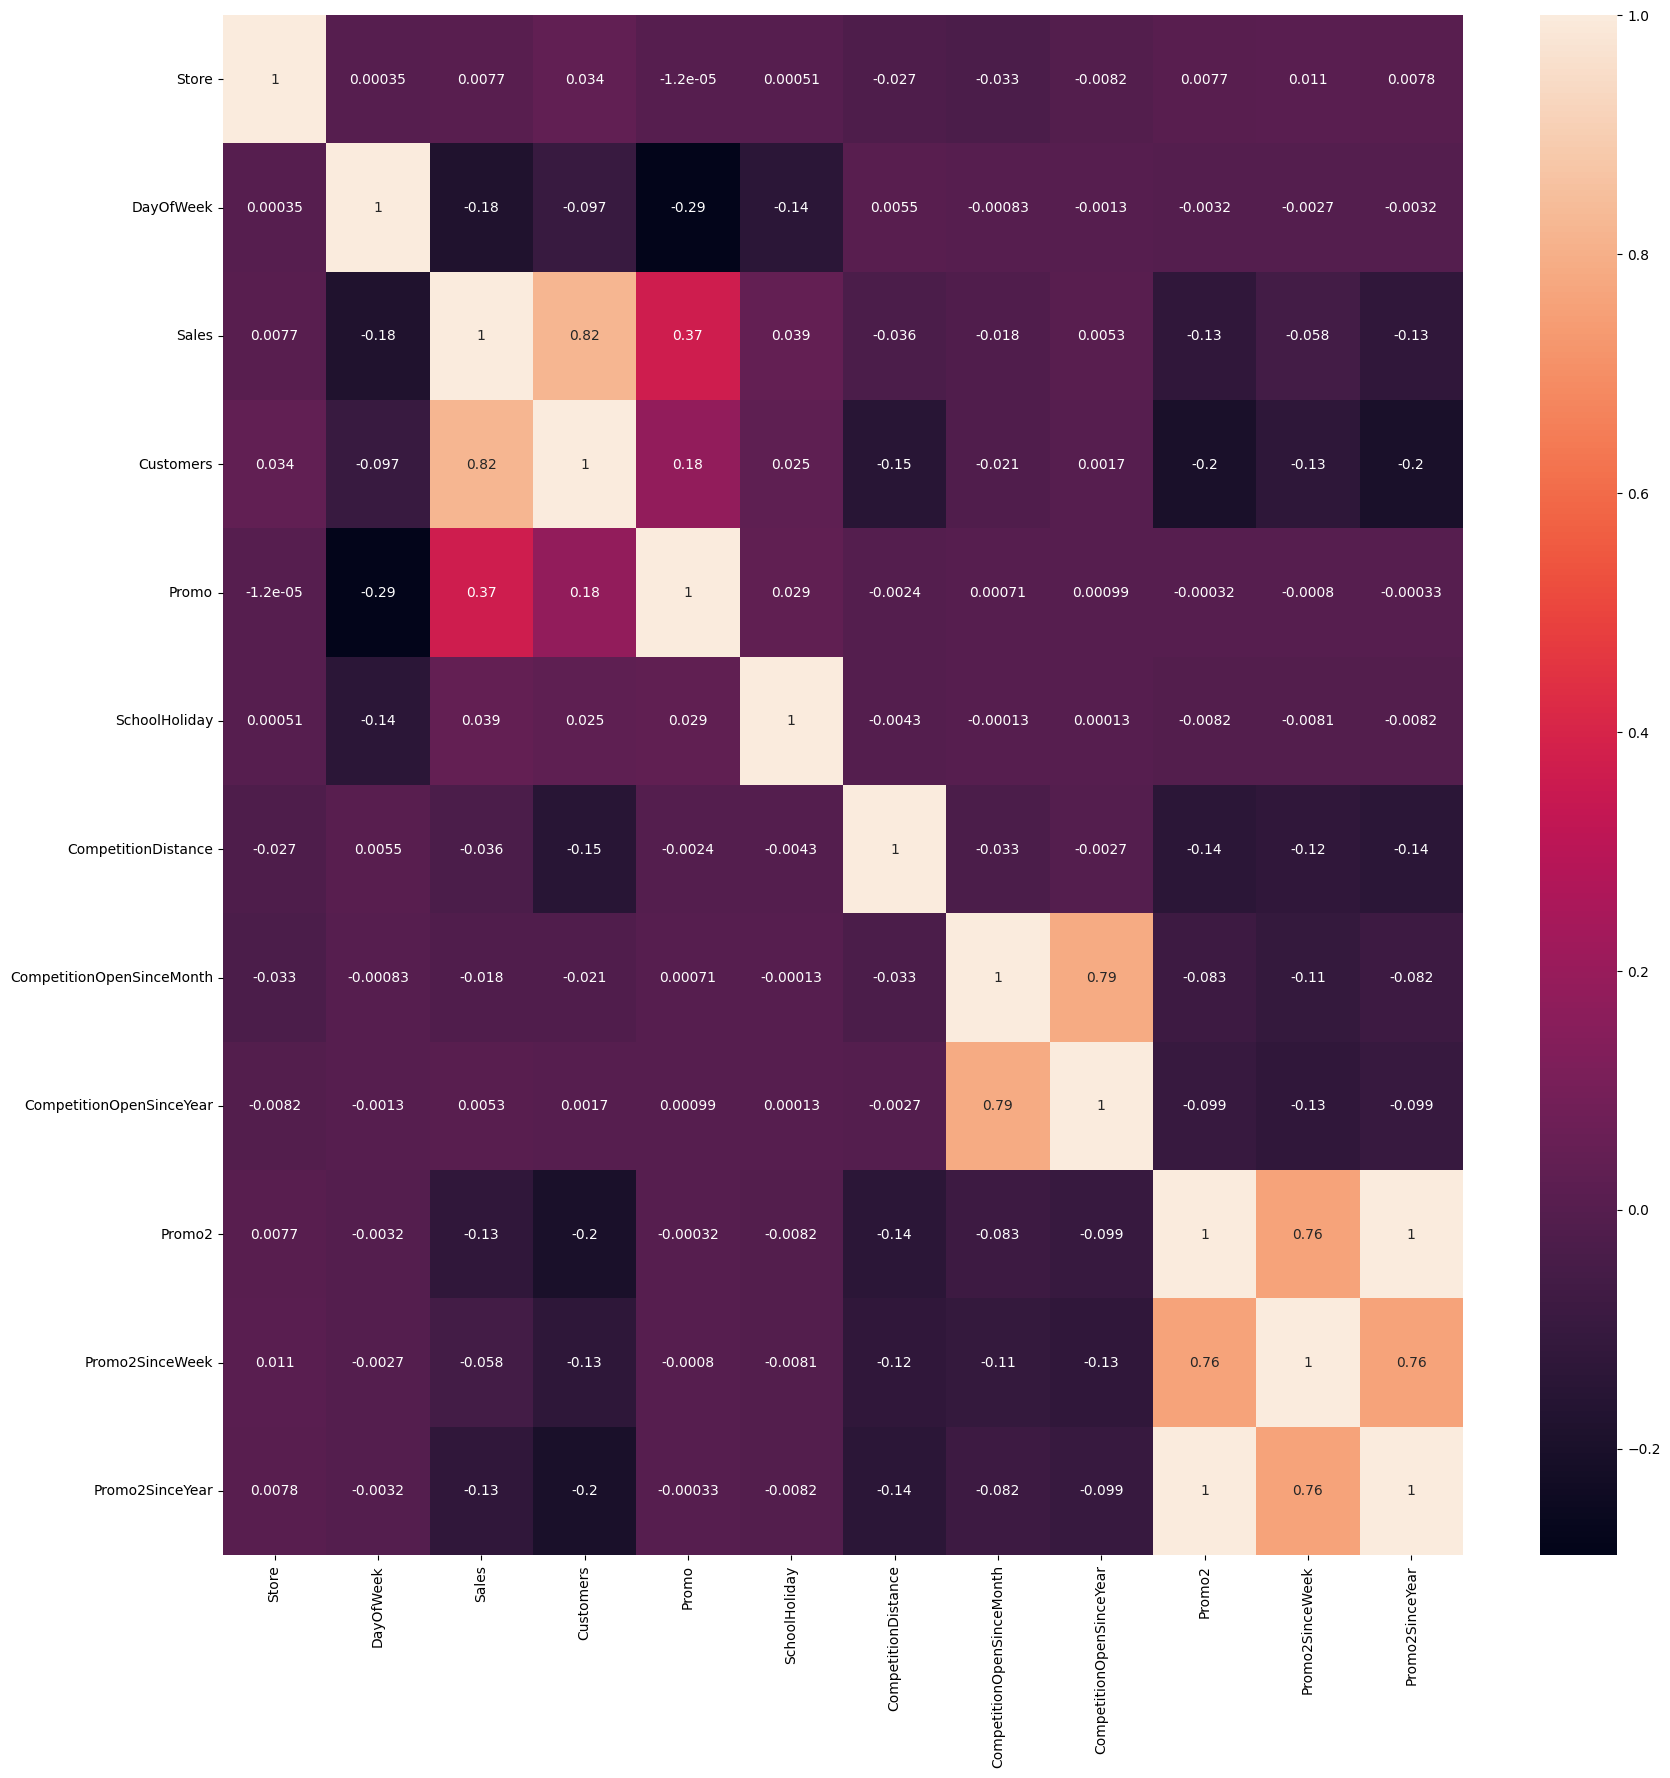

In [42]:
correlations = sales_train_all_df.select_dtypes(include=['number']).corr()

f, ax = plt.subplots(figsize=(20,20))
sns.heatmap(correlations, annot=True)
plt.show()
# Customers/Prmo2 and sales are strongly correlated

### Correlation Heatmap Observations

- **Customers** has the strongest positive correlation with **Sales (0.82)**, indicating that higher customer traffic directly drives higher sales.
- **Promo** shows a moderate positive correlation with **Sales (0.37)**, suggesting that promotional campaigns generally increase sales performance.
- **DayOfWeek** has a weak negative correlation with **Sales (-0.18)**, indicating sales vary across different days of the week.
- **CompetitionDistance** has a weak negative correlation with **Sales (-0.04)**, implying competitor distance has limited impact on store sales.
- **Promo2**, **Promo2SinceWeek**, and **Promo2SinceYear** exhibit weak negative correlations with **Sales**, suggesting the long-term promotion program has limited direct influence on sales.
- **CompetitionOpenSinceMonth** and **CompetitionOpenSinceYear** are strongly correlated (**0.79**), as both describe when competitors entered the market.
- **Promo2**, **Promo2SinceYear**, and **Promo2SinceWeek** are highly correlated (**0.76–1.00**), indicating these variables capture similar promotion-related information.

Customer count is the most influential factor affecting sales, followed by promotional activities. Competition-related variables and long-term promotion features show relatively weak relationships with sales.

In [43]:
# Let's separate the year and put it into a separate column
sales_train_all_df['Year'] = pd.DatetimeIndex(sales_train_all_df['Date']).year

In [45]:
sales_train_all_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,0,2013
844388,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,0,2013
844389,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,0.0,0.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013
844390,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,0.0,0.0,0,0.0,0.0,0,2013


# 8. Feature Engineering

## Extracting Date-Based Features

Date information contains valuable seasonal patterns.

To capture these patterns, the Date column is decomposed into:

- Year
- Month
- Day

These features help identify trends, seasonality, and recurring sales patterns.

In [46]:
# Let's do the same for the Day and Month
sales_train_all_df['Month'] = pd.DatetimeIndex(sales_train_all_df['Date']).month
sales_train_all_df['Day'] = pd.DatetimeIndex(sales_train_all_df['Date']).day

In [47]:
sales_train_all_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7,31
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,0,2013,1,1
844388,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,0,2013,1,1
844389,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,0.0,0.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1
844390,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,0.0,0.0,0,0.0,0.0,0,2013,1,1


# 9. Sales Trend Analysis

## Monthly Sales Patterns

One of the most important aspects of sales forecasting is understanding seasonality.

This analysis investigates how sales and customer traffic vary throughout the year and identifies peak and low-performing periods.

Text(0.5, 1.0, 'Average Customers Per Month')

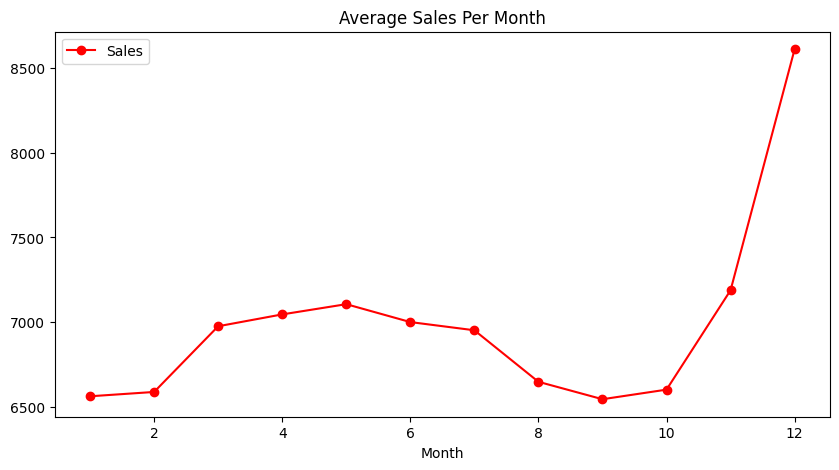

<Figure size 640x480 with 0 Axes>

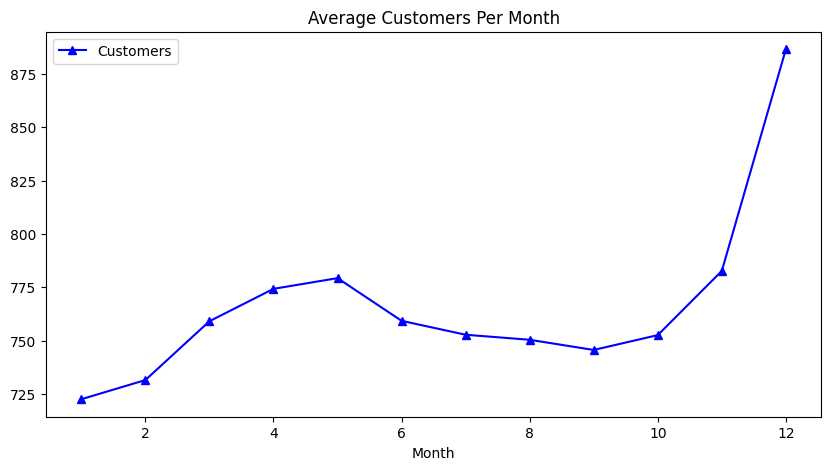

In [48]:
# Let's take a look at the average sales and number of customers per month
# 'groupby' works great by grouping all the data that share the same month column, then obtain the mean of the sales column
# It looks like sales and number of customers peak around christmas timeframe
axis = sales_train_all_df.groupby('Month')[['Sales']].mean().plot(figsize = (10,5), marker = 'o', color = 'r')
axis.set_title('Average Sales Per Month')

plt.figure()
axis = sales_train_all_df.groupby('Month')[['Customers']].mean().plot(figsize = (10,5), marker = '^', color = 'b')
axis.set_title('Average Customers Per Month')


### Monthly Sales and Customer Trends

- Both **Sales** and **Customer Count** follow a very similar pattern throughout the year, indicating a strong positive relationship between customer traffic and sales revenue.
- Sales and customer numbers gradually increase during the first half of the year, reaching a peak around the middle months.
- A decline is observed during the later months, followed by a recovery toward the end of the year.
- The highest sales and customer traffic occur in the final month, suggesting a strong seasonal effect, likely driven by holiday shopping and year-end promotions.
- Periods with higher customer counts consistently correspond to higher sales, reinforcing the importance of customer footfall as a key sales driver.

Customer traffic is a major determinant of sales performance, and both metrics exhibit clear seasonal trends with a significant year-end surge.

## Daily Sales Behavior

Customer activity often varies throughout the month.

This analysis examines how sales and customer traffic fluctuate across different days of the month.

Text(0.5, 1.0, 'Average Sales Per Day')

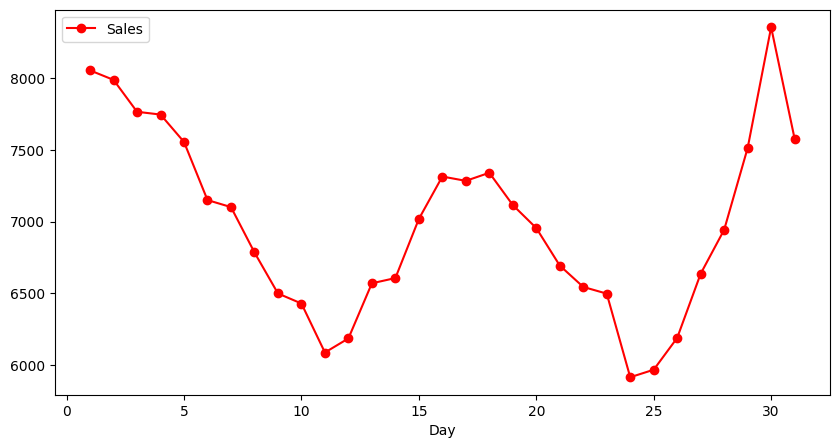

<Figure size 640x480 with 0 Axes>

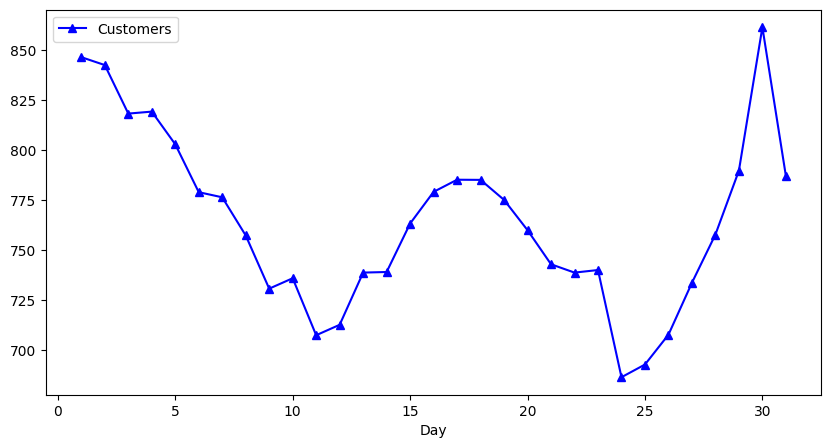

In [49]:
# Let's take a look at the sales and customers per day of the month instead
# Minimum number of customers are generally around the 24th of the month
# Most customers and sales are around 30th and 1st of the month
ax = sales_train_all_df.groupby('Day')[['Sales']].mean().plot(figsize = (10,5), marker = 'o', color = 'r')
axis.set_title('Average Sales Per Day')

plt.figure()
ax = sales_train_all_df.groupby('Day')[['Customers']].mean().plot(figsize = (10,5), marker = '^', color = 'b')
axis.set_title('Average Sales Per Day')


### Daily Sales and Customer Trends

- Daily **Sales** and **Customer Count** exhibit very similar patterns, indicating a strong positive relationship between customer traffic and revenue.
- Both metrics decline during the first half of the month, reaching a low point around days **11–12**.
- Sales and customer numbers recover during the middle of the month, followed by another dip around **days 24–25**.
- A sharp increase is observed during the final days of the month, with both metrics reaching their highest values around **day 30**.
- The end-of-month surge suggests increased customer activity, potentially driven by salary cycles, promotions, or seasonal shopping behavior.
- Peaks and troughs in customer traffic closely mirror those in sales, reinforcing that customer volume is a key driver of store performance.

Daily sales are strongly influenced by customer footfall, with clear cyclical patterns and a significant spike at the end of the month.

## Weekly Sales Patterns

Retail sales often follow predictable weekly cycles.

Analyzing sales by day of the week helps identify high-demand and low-demand periods.

Text(0.5, 1.0, 'Average Customers Per Day of the Week')

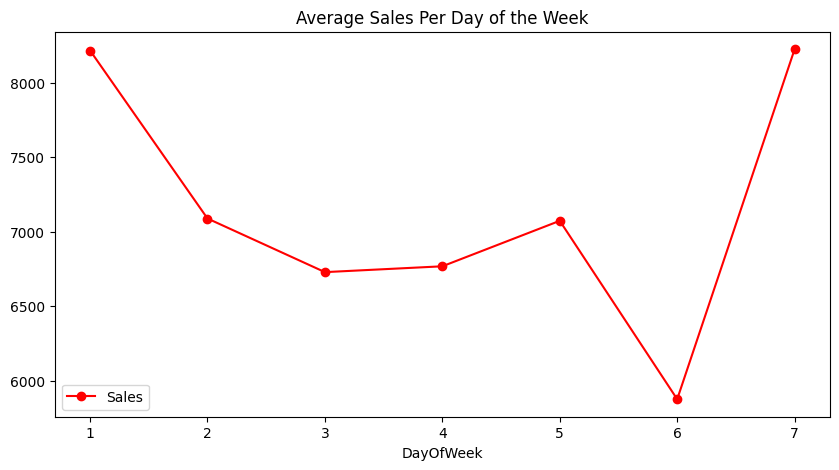

<Figure size 640x480 with 0 Axes>

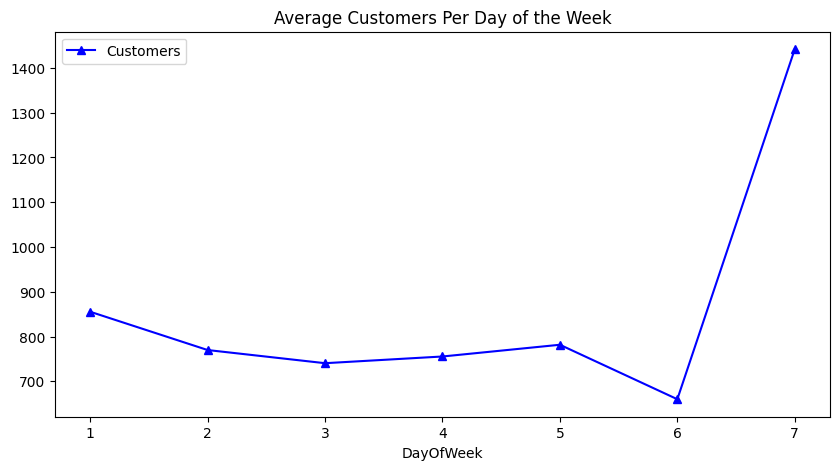

In [50]:
# Let's do the same for the day of the week  (note that 7 = Sunday)

axis = sales_train_all_df.groupby('DayOfWeek')[['Sales']].mean().plot(figsize = (10,5), marker = 'o', color = 'r')
axis.set_title('Average Sales Per Day of the Week')

plt.figure()
axis = sales_train_all_df.groupby('DayOfWeek')[['Customers']].mean().plot(figsize = (10,5), marker = '^', color = 'b')
axis.set_title('Average Customers Per Day of the Week')


### Sales and Customer Trends by Day of the Week

- Sales and customer traffic follow a very similar weekly pattern, indicating a strong positive relationship between the two metrics.
- **Day 7** records the highest average sales and customer count, making it the busiest day of the week.
- **Day 1** also shows strong performance, with relatively high sales and customer traffic.
- **Days 3 and 4** experience moderate sales and customer activity compared to other days.
- **Day 6** records the lowest average sales and customer count, indicating reduced store activity.
- The close alignment between the sales and customer curves suggests that customer footfall is a key driver of revenue generation.

Sales performance varies significantly across the week, with Days **7 and 1** generating the highest revenue and customer traffic, while Day **6** represents the weakest performing day.

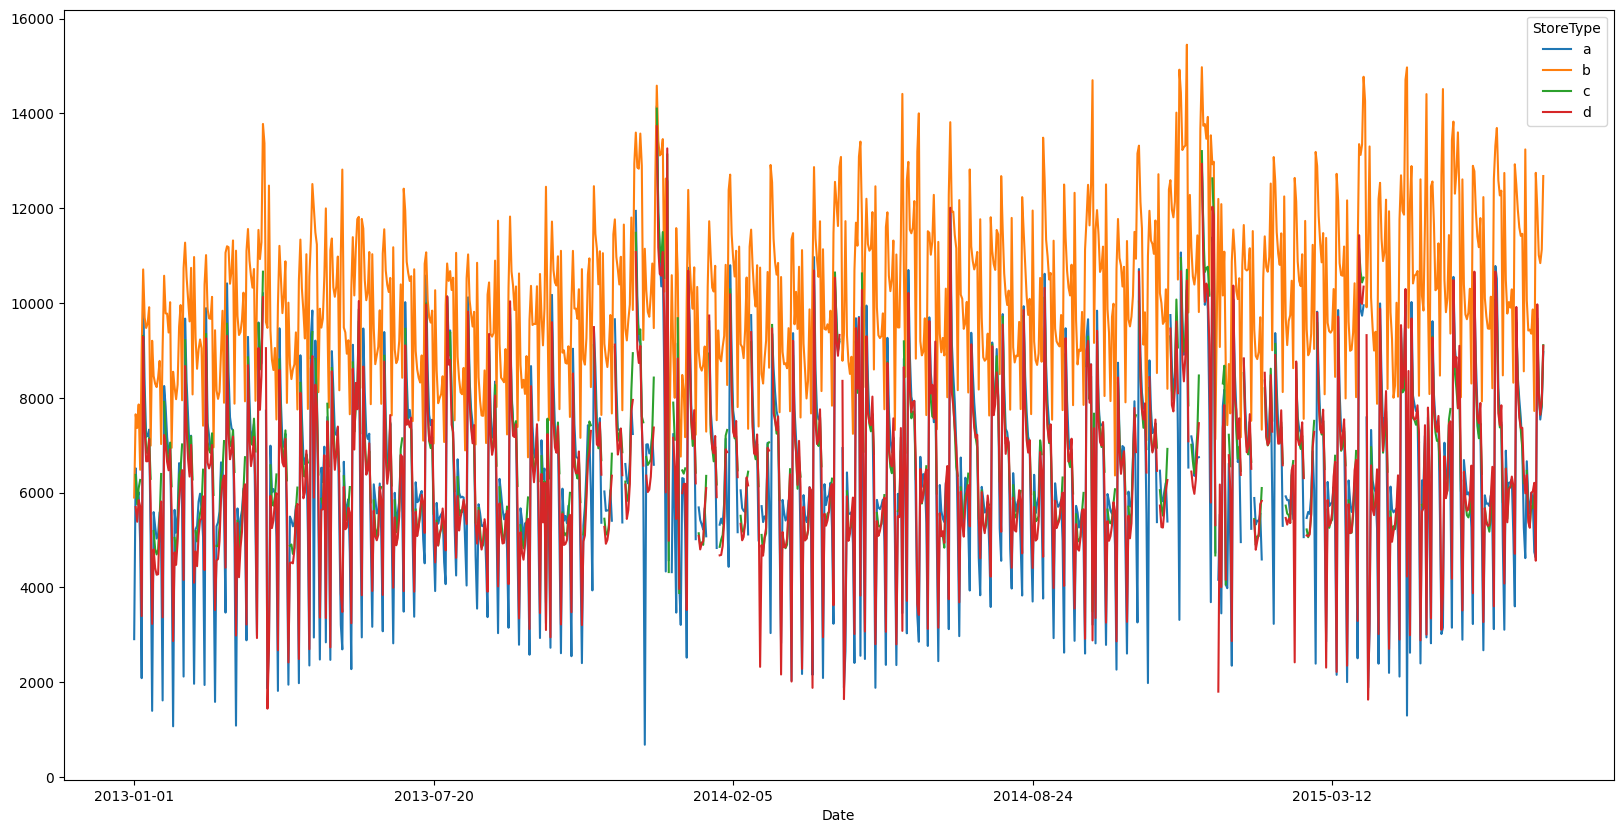

In [53]:
fig, ax = plt.subplots(figsize=(20,10))

sales_train_all_df.groupby(['Date','StoreType'])['Sales'] \
                  .mean() \
                  .unstack() \
                  .plot(ax=ax)

plt.show()

### Sales Trends by Store Type

- **Store Type B** consistently records the highest average sales throughout the period, significantly outperforming the other store types.
- **Store Types A, C, and D** exhibit relatively similar sales patterns, although Store Type D generally achieves slightly higher sales than A and C.
- All store types show noticeable fluctuations over time, indicating the influence of seasonality, promotions, holidays, and customer demand.
- Periodic spikes in sales are observed across all store types, suggesting common seasonal or promotional effects affecting the entire retail network.
- Store Type B not only generates the highest sales but also shows larger sales variability, indicating greater customer traffic and revenue potential.
- Despite short-term fluctuations, the overall sales performance of each store type remains relatively stable over the observed period.

 Store Type B is the strongest-performing store category, while Store Types A, C, and D contribute moderate but consistent sales. Store type appears to be an important factor influencing sales performance and should be included in forecasting models.

# 10. Promotional Impact Analysis

## Objective

Promotions are one of the most important factors affecting sales performance.

This analysis evaluates the impact of promotional campaigns on:

- Sales Revenue
- Customer Traffic

Understanding promotional effectiveness helps optimize future marketing strategies.

<Axes: xlabel='Promo', ylabel='Customers'>

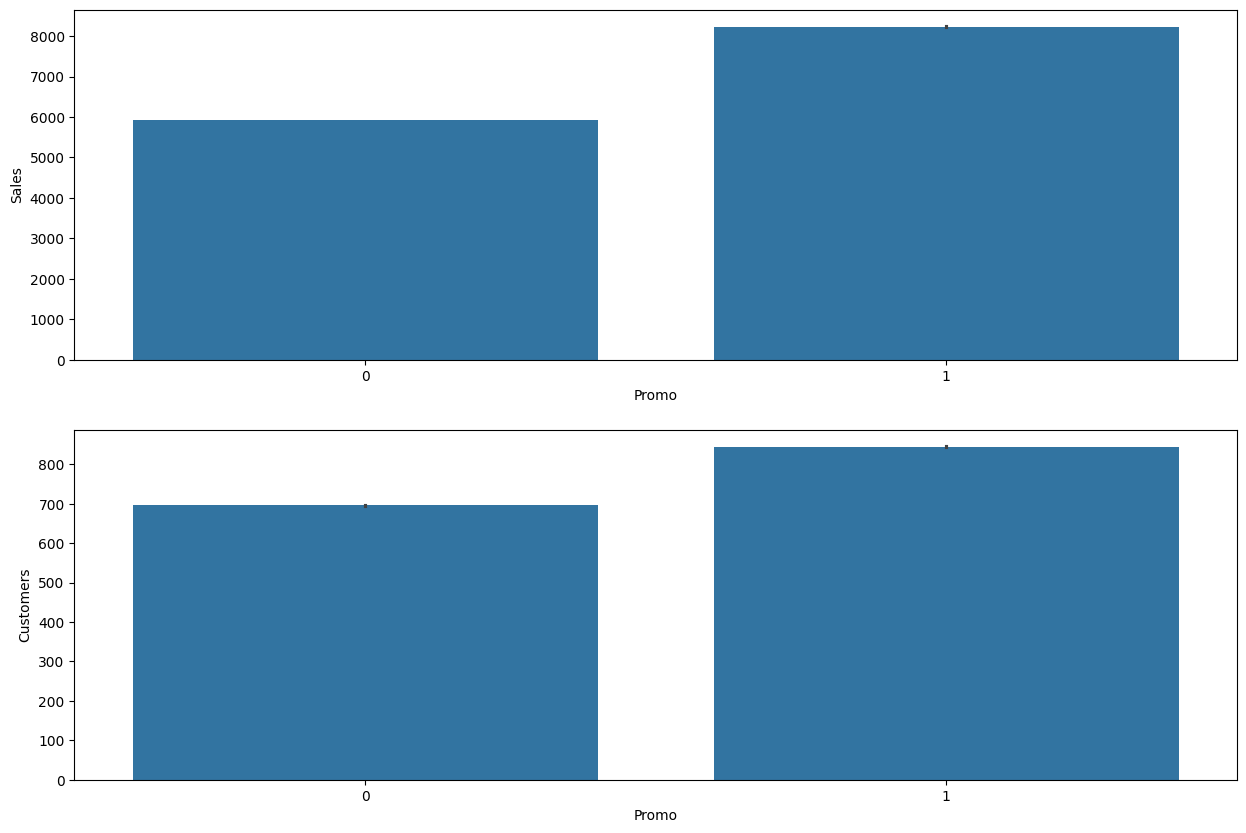

In [54]:
plt.figure(figsize=[15,10])

plt.subplot(211)
sns.barplot(x = 'Promo', y = 'Sales', data = sales_train_all_df)

plt.subplot(212)
sns.barplot(x = 'Promo', y = 'Customers', data = sales_train_all_df)

### Impact of Promotions on Sales and Customers

- Stores running a **promotion (Promo = 1)** achieve noticeably higher average sales compared to periods without promotions.
- Average sales increase from approximately **5,900** to **8,200**, indicating a substantial positive impact of promotional campaigns.
- Customer traffic also increases during promotional periods, rising from roughly **700** to **850** customers on average.
- The higher customer count during promotions suggests that promotions effectively attract more shoppers to stores.
- The simultaneous increase in both sales and customer traffic indicates that promotions not only drive store visits but also contribute to higher revenue generation.

 Promotional campaigns have a strong positive effect on both customer footfall and sales performance, making promotions an important driver of retail revenue.

<Axes: xlabel='Promo', ylabel='Customers'>

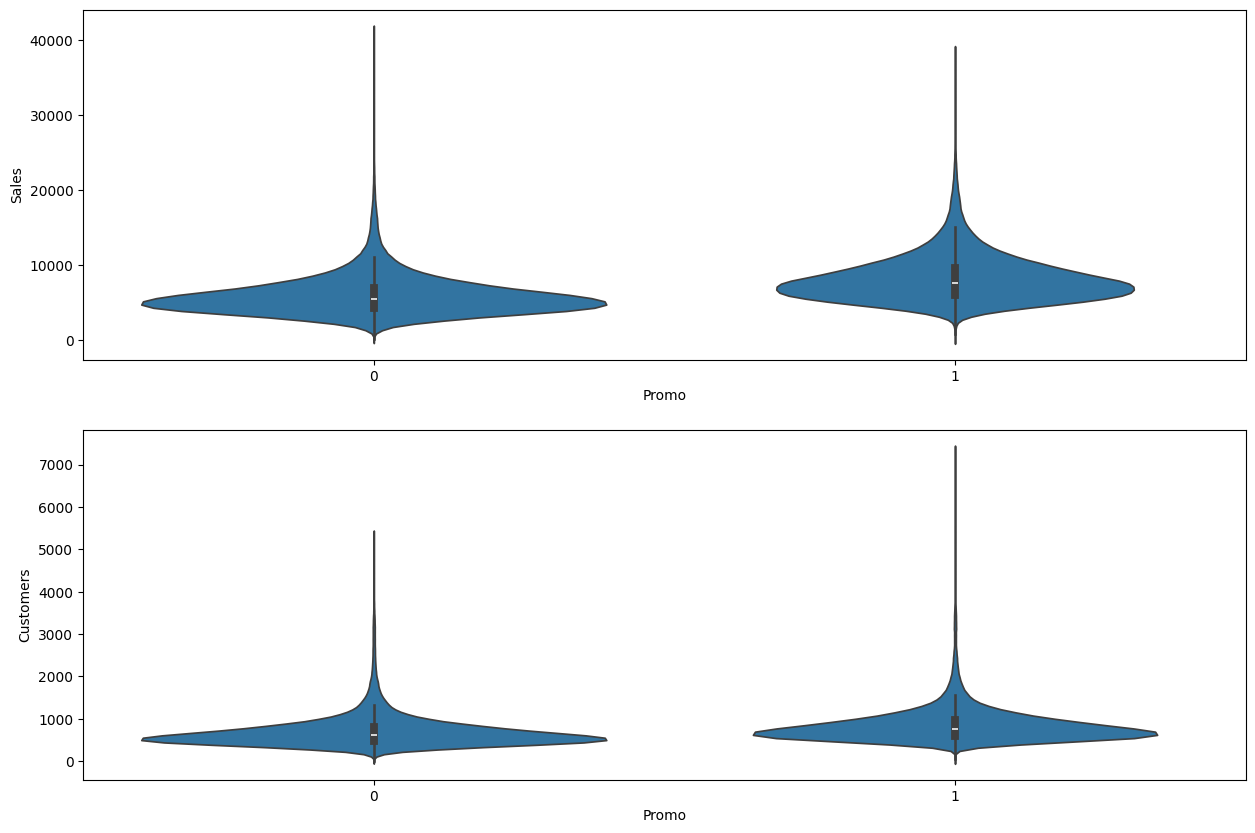

In [55]:
plt.figure(figsize=[15,10])

plt.subplot(211)
sns.violinplot(x = 'Promo', y = 'Sales', data = sales_train_all_df)

plt.subplot(212)
sns.violinplot(x = 'Promo', y = 'Customers', data = sales_train_all_df)

### Promotion Impact Analysis (Violin Plots)

- Stores running **promotions (Promo = 1)** show a higher distribution of both **Sales** and **Customers** compared to non-promotional periods.
- The median sales during promotions are noticeably higher, indicating that promotions consistently boost revenue.
- Customer counts are also higher when promotions are active, suggesting that promotions successfully attract more shoppers.
- The distribution for promotional periods is wider, reflecting greater variability and higher peak values in both sales and customer traffic.
- Both promotional and non-promotional periods contain some extreme values (outliers), but the highest sales and customer counts are predominantly observed during promotions.
- The upward shift in the entire distribution indicates that the positive impact of promotions is not limited to a few stores but is observed across a large portion of the dataset.

 The violin plots confirm that promotions significantly increase customer footfall and sales revenue, making promotional campaigns one of the strongest drivers of store performance.

# 11. Time Series Forecasting Using Prophet

## Objective

The goal of this stage is to build a forecasting model capable of predicting future sales based on historical trends.

Facebook Prophet is selected because it can effectively model:

- Trend
- Seasonality
- Holiday Effects
- Long-Term Patterns

The model learns historical sales behavior and generates future forecasts.

In [58]:
!pip install prophet
from prophet import Prophet


In [59]:
def sales_prediction(Store_ID, sales_df, periods):
  # Function that takes in the data frame, storeID, and number of future period forecast
  # The function then generates date/sales columns in Prophet format
  # The function then makes time series predictions

  sales_df = sales_df[ sales_df['Store'] == Store_ID ]
  sales_df = sales_df[['Date', 'Sales']].rename(columns = {'Date': 'ds', 'Sales':'y'})
  sales_df = sales_df.sort_values('ds')

  model    = Prophet()
  model.fit(sales_df)
  future   = model.make_future_dataframe(periods=periods)
  forecast = model.predict(future)
  figure   = model.plot(forecast, xlabel='Date', ylabel='Sales')
  figure2  = model.plot_components(forecast)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


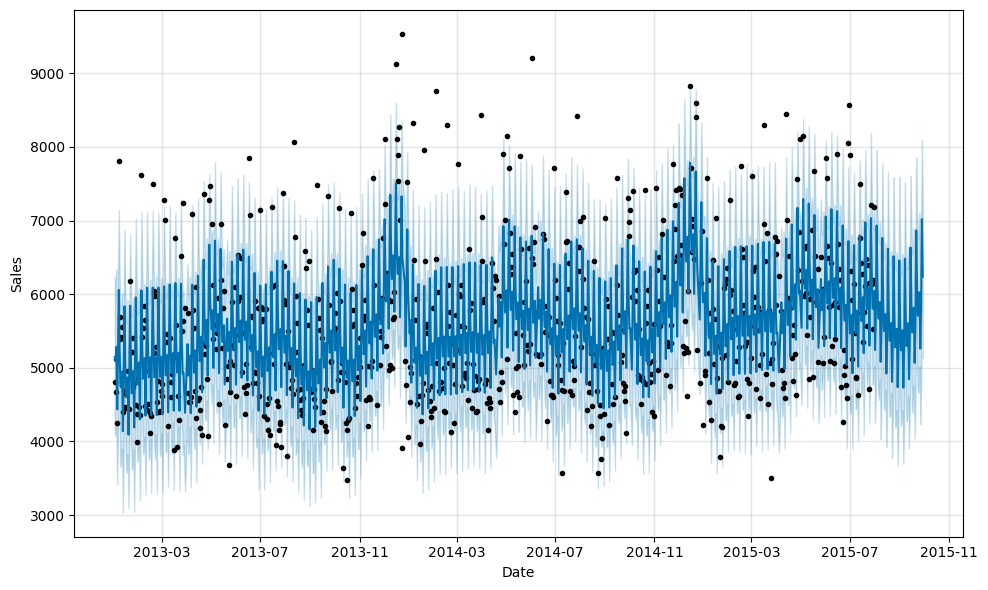

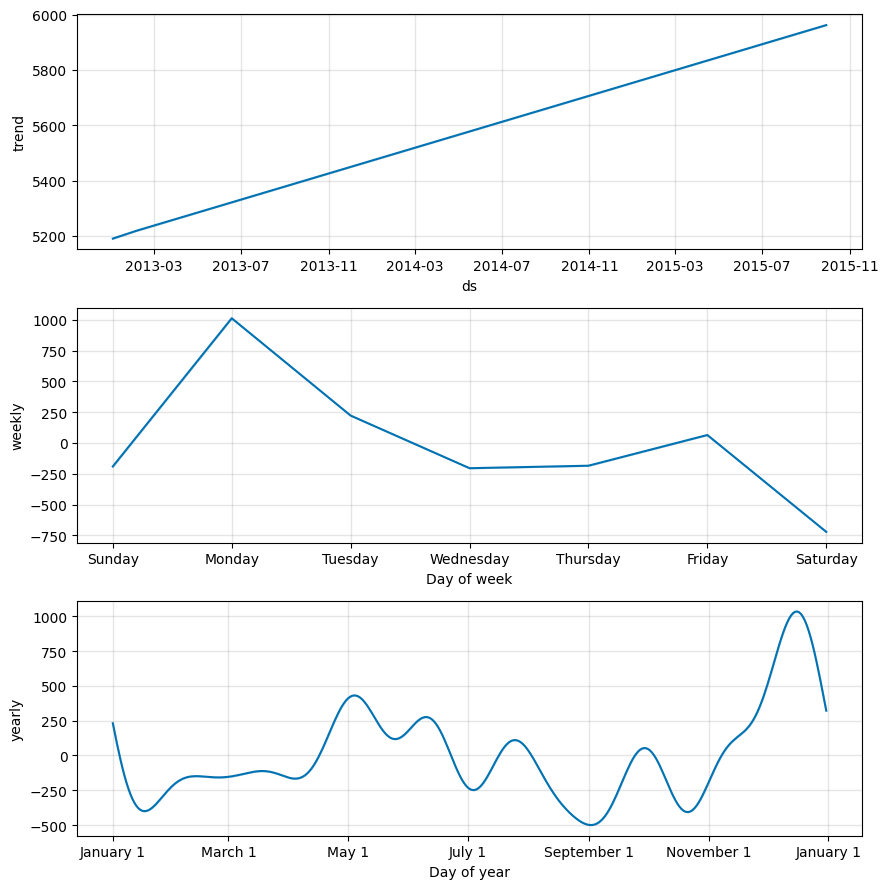

In [60]:
sales_prediction(10, sales_train_all_df, 60)

### Prophet Model Components Analysis

#### Trend Component
- The trend line shows a steady upward movement over time, indicating gradual growth in overall sales throughout the observed period.
- This suggests that the business is experiencing long-term positive sales growth.

#### Weekly Seasonality
- **Monday** generates the strongest positive effect on sales.
- **Saturday** shows the largest negative impact on sales.
- Sales remain moderately positive on Tuesday and Friday, while Wednesday and Thursday contribute slightly below average sales.
- This confirms that customer purchasing behavior varies significantly across the week.

#### Yearly Seasonality
- Sales exhibit clear seasonal fluctuations throughout the year.
- Strong positive seasonal effects are observed toward the **end of the year**, particularly during November and December.
- Lower sales periods appear around the middle of the year and early autumn.
- These patterns likely reflect holiday shopping periods, promotions, and seasonal demand changes.





Overall, the forecast demonstrates that sales are expected to continue following an upward trend while maintaining strong weekly and annual seasonal patterns, making Prophet an effective model for retail sales forecasting.

# 12. Advanced Forecasting with Holiday Effects

## Why Holidays Matter

Sales behavior changes significantly during holidays.

Examples include:

- Christmas
- Easter
- Public Holidays
- School Holidays

To improve forecasting accuracy, holiday information is incorporated into the forecasting model.

This allows Prophet to learn how special events influence store sales.

In [61]:
def sales_prediction(Store_ID, sales_df, holidays, periods):
  # Function that takes in the storeID and returns two date/sales columns in Prophet format
  # Format data to fit prophet

  sales_df = sales_df[ sales_df['Store'] == Store_ID ]
  sales_df = sales_df[['Date', 'Sales']].rename(columns = {'Date': 'ds', 'Sales':'y'})
  sales_df = sales_df.sort_values('ds')

  model    = Prophet(holidays = holidays)
  model.fit(sales_df)
  future   = model.make_future_dataframe(periods = periods)
  forecast = model.predict(future)
  figure   = model.plot(forecast, xlabel='Date', ylabel='Sales')
  figure2  = model.plot_components(forecast)

### Holiday Feature Construction

Holiday dates are extracted and formatted according to Prophet requirements.

Both state holidays and school holidays are combined into a unified holiday dataset that will be used during model training.

In [62]:
# Get all the dates pertaining to school holidays
school_holidays = sales_train_all_df[sales_train_all_df['SchoolHoliday'] == 1].loc[:, 'Date'].values
school_holidays.shape

(163457,)

In [63]:
school_holidays

array(['2015-07-31', '2015-07-31', '2015-07-31', ..., '2013-01-01',
       '2013-01-01', '2013-01-01'], dtype=object)

In [64]:
# Get all the dates pertaining to state holidays
state_holidays = sales_train_all_df [ (sales_train_all_df['StateHoliday'] == 'a') | (sales_train_all_df['StateHoliday'] == 'b') | (sales_train_all_df['StateHoliday'] == 'c')  ].loc[:, 'Date'].values
state_holidays.shape

(910,)

In [65]:
state_holidays = pd.DataFrame({'ds': pd.to_datetime(state_holidays),
                               'holiday': 'state_holiday'})

In [66]:
state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
905,2013-01-01,state_holiday
906,2013-01-01,state_holiday
907,2013-01-01,state_holiday
908,2013-01-01,state_holiday


In [67]:
school_holidays = pd.DataFrame({'ds': pd.to_datetime(school_holidays),
                                'holiday': 'school_holiday'})

In [68]:
school_holidays

,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-31,school_holiday
2,2015-07-31,school_holiday
3,2015-07-31,school_holiday
4,2015-07-31,school_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


In [69]:
# concatenate both school and state holidays
school_state_holidays = pd.concat((state_holidays, school_holidays))

In [70]:
school_state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


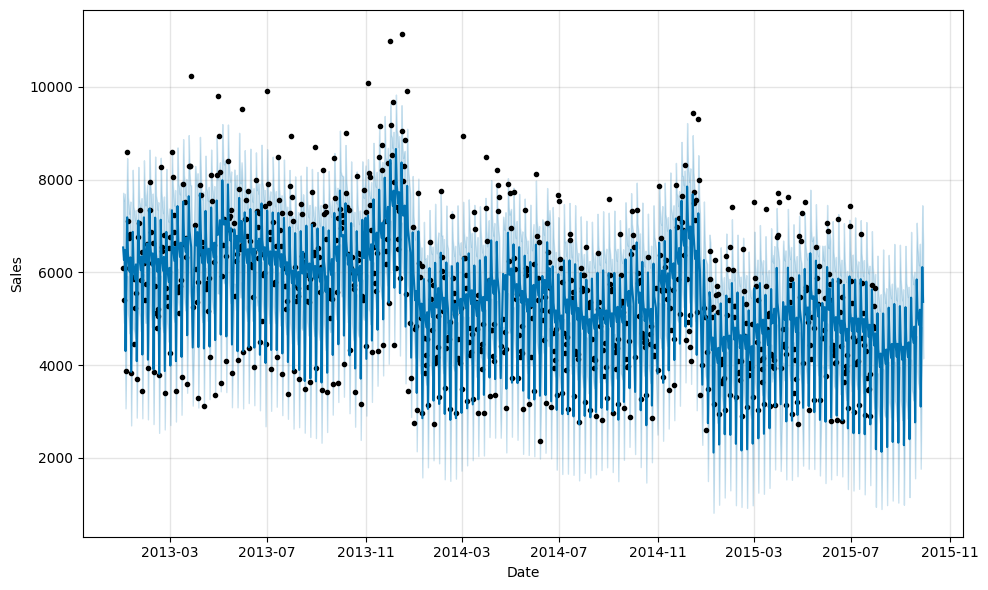

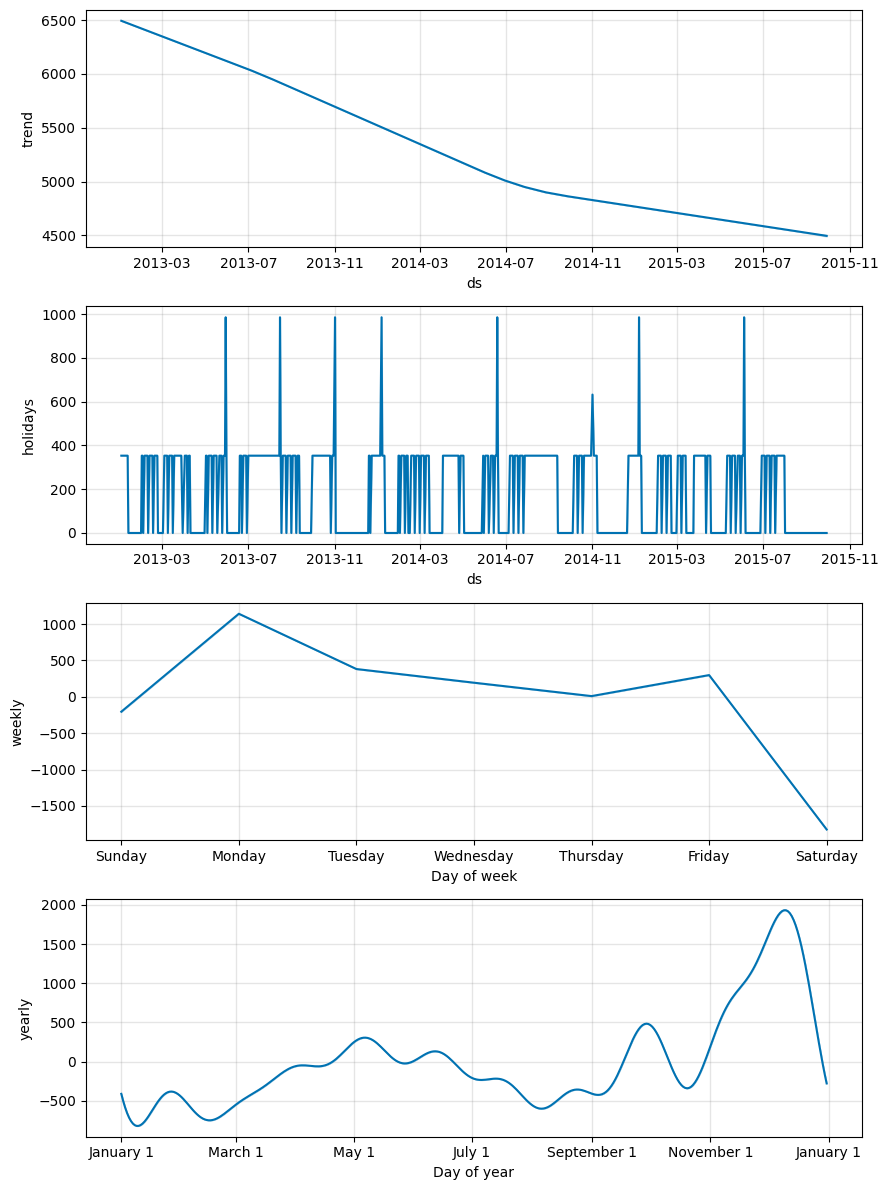

In [71]:
# Let's make predictions using holidays for a specific store
sales_prediction(6, sales_train_all_df, school_state_holidays, 60)

### Prophet Forecast Analysis with Holidays

#### Forecast Performance
- The forecast captures the overall sales pattern and seasonal fluctuations reasonably well.
- Actual sales values generally fall within the confidence interval, indicating satisfactory model performance.
- Weekly sales cycles are clearly reflected throughout the forecast horizon.

#### Trend Component
- The long-term trend shows a gradual decline in sales from approximately 6,500 to 4,500 over the observed period.
- This suggests a decrease in baseline sales performance over time after accounting for seasonality and holiday effects.

#### Holiday Effects
- Holiday periods generate significant positive spikes in sales.
- Certain holidays contribute sales increases of nearly 1,000 units above the baseline trend.
- The recurring spikes confirm that special events and holidays strongly influence customer purchasing behavior.

#### Weekly Seasonality
- **Monday** produces the strongest positive impact on sales.
- **Saturday** has the largest negative impact, indicating the weakest sales performance during the week.
- Tuesday and Friday contribute moderate positive effects.
- Wednesday and Thursday remain close to the average sales level.

#### Yearly Seasonality
- Strong seasonal peaks occur during the final months of the year, especially around November and December.
- Lower sales periods appear during January, February, and late summer months.
- This pattern reflects holiday shopping demand and annual retail seasonality.

### Key Insights
- Holiday events significantly boost sales and should be incorporated into forecasting models.
- Mondays consistently outperform other weekdays.
- Sales experience strong year-end seasonal growth.
- Despite seasonal peaks, the underlying long-term sales trend is declining.

### Conclusion
The Prophet model successfully captures trend, weekly seasonality, yearly seasonality, and holiday effects. Results indicate that while holidays and year-end periods drive substantial sales increases, the underlying sales trend shows a gradual decline over time. Incorporating holiday information improves forecast accuracy and provides a more realistic representation of retail demand patterns.